# Customer Churn Analysis
## Author: Devon Wildman

In [62]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [63]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Dataset Overview
The dataset contains customer information including demographics, services, and churn status.

In [65]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()

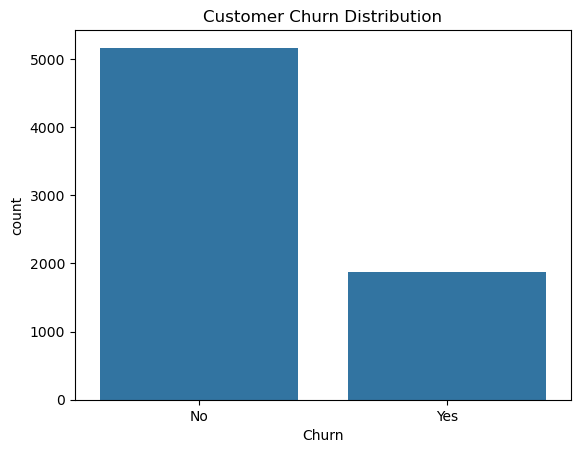

In [66]:
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.show()

### Insight
The majority of customers do not churn, indicating class imbalance in the dataset.

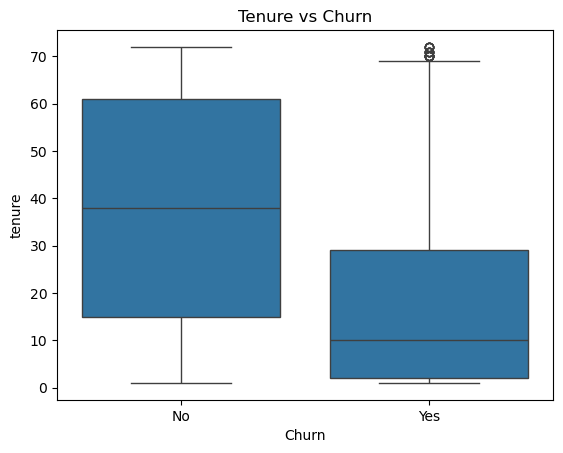

In [68]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure vs Churn")
plt.show()

### Insight
Customers with shorter tenure are more likely to churn. This suggests early customer experience is critical for retention.

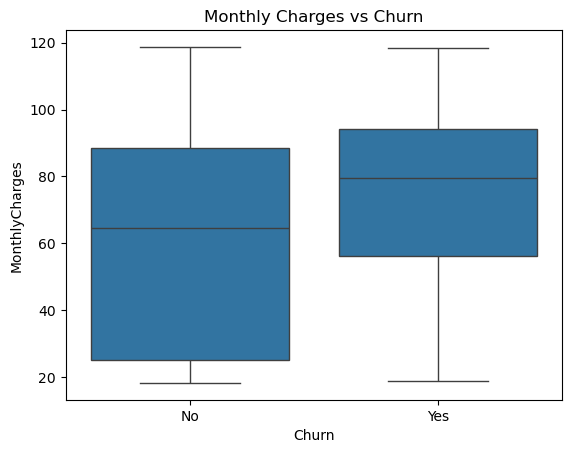

In [70]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

### Insight
Customers with higher monthly charges tend to churn more, indicating price sensitivity.

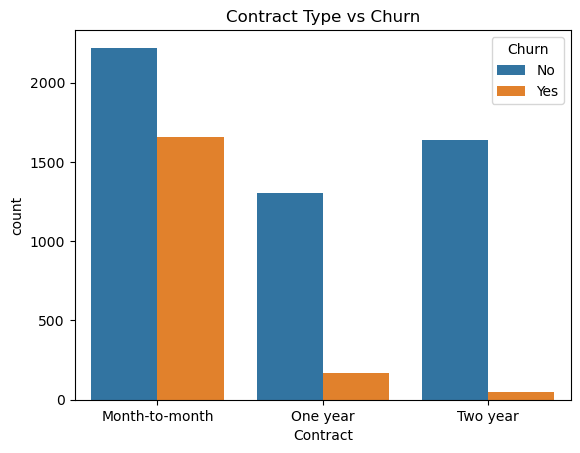

In [72]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Contract Type vs Churn")
plt.show()

### Insight
Customers on month-to-month contracts are significantly more likely to churn compared to long-term contracts.

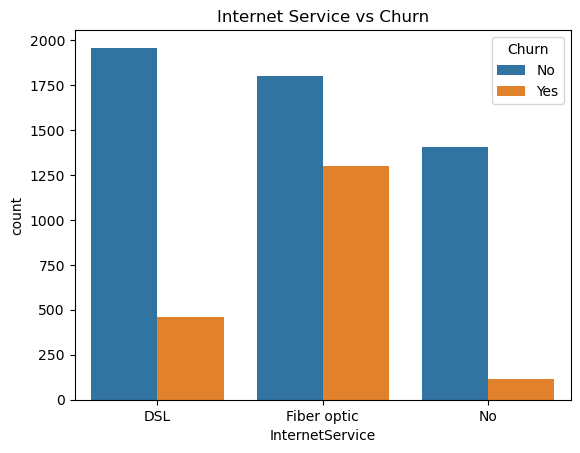

In [74]:
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.title("Internet Service vs Churn")
plt.show()

### Insight
Customers using fiber optic internet show higher churn rates, possibly due to higher costs or service expectations.

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

### Data Preparation
Categorical variables were encoded into numerical values using Label Encoding to prepare the dataset for machine learning.

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Train-Test Split
The dataset was split into training and testing sets (80/20) to evaluate model performance.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

### Model Training
A Random Forest Classifier was used to predict customer churn due to its robustness and ability to handle complex relationships.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

### Model Evaluation
The model was evaluated using accuracy and classification metrics such as precision, recall, and F1-score.

In [ ]:
import pandas as pd

importance = model.feature_importances_
features = X.columns

feat_imp = pd.Series(importance, index=features).sort_values(ascending=False)

print(feat_imp.head(10))

### Feature Importance
The model identified the most important factors influencing churn, such as tenure, contract type, and monthly charges.